# ***1) Importing libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
from transformers import pipeline

# ***2) Importing DataSet***

In [2]:
df = pd.read_csv("/content/data_urls_final.csv")

# ***3) Exploratory data analysis (EDA)***

In [3]:
df.shape

(1451, 88)

### **Comment**: 11357 rows and 88 columns

In [4]:
df.head()

,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,PopularUserTags,Has_Support_Link,Support_Tier,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,Header_Size_Group,ReleaseYear,Website_Authority
0,10,10,Counter-Strike,Counter-Strike,Nov 1 2000,0,0,1,0,88,...,"Action, FPS, Multiplayer, Shooter, Classic, Te...",1.0,Community_Social,28138.0,1.0,50690.0,1.0,Small,2000.0,NaN
1,20,20,Team Fortress Classic,Team Fortress Classic,Apr 1 1999,0,0,1,0,0,...,"Action, FPS, Multiplayer, Classic, Hero Shoote...",0.0,NaN,30412.0,1.0,64709.0,1.0,Small,1999.0,NaN
2,30,30,Day of Defeat,Day of Defeat,May 1 2003,0,0,1,0,79,...,"FPS, World War II, Multiplayer, Shooter, Actio...",0.0,NaN,36605.0,1.0,58479.0,1.0,Medium,2003.0,Custom_Studio
3,40,40,Deathmatch Classic,Deathmatch Classic,Jun 1 2001,0,0,1,0,0,...,"Action, FPS, Classic, Multiplayer, Shooter, Fi...",0.0,NaN,32228.0,1.0,39026.0,1.0,Small,2001.0,NaN
4,50,50,Half-Life: Opposing Force,Half-Life: Opposing Force,Nov 1 1999,0,0,1,0,0,...,"FPS, Action, Classic, Sci-fi, Singleplayer, Sh...",0.0,NaN,41595.0,1.0,37607.0,1.0,Medium,1999.0,NaN


In [5]:
df.tail()

,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,PopularUserTags,Has_Support_Link,Support_Tier,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,Header_Size_Group,ReleaseYear,Website_Authority
1446,209100,209100,Resident Evil™: Operation Raccoon City,Resident Evil: Operation Raccoon City,May 18 2012,17,0,1,8,48,...,"Action, Zombies, Multiplayer, Co-op, Horror, T...",1.0,Professional_Portal,41635.0,1.0,48344.0,1.0,Medium,2012.0,Has_Social_Only
1447,209120,209120,Street Fighter X Tekken,Street Fighter X Tekken,May 11 2012,0,0,1,61,79,...,"Fighting, Action, 2D Fighter, Arcade, Multipla...",1.0,General_Website,52697.0,1.0,79039.0,1.0,Large,2012.0,Custom_Studio
1448,209160,209160,Call of Duty: Ghosts,Call of Duty(r): Ghosts,Mar 25 2014,17,0,1,51,68,...,"Dog, FPS, Action, Multiplayer, Shooter, First-...",1.0,Professional_Portal,30990.0,1.0,70214.0,1.0,Small,2014.0,Custom_Studio
1449,209170,209160,Call of Duty: Ghosts - Multiplayer,Call of Duty(r): Ghosts,Mar 25 2014,17,0,1,51,68,...,"Dog, FPS, Action, Multiplayer, Shooter, First-...",1.0,Professional_Portal,30990.0,1.0,70214.0,1.0,Small,2014.0,Custom_Studio
1450,209230,209230,Sherlock Holmes and The Hound of The Baskervilles,Sherlock Holmes and The Hound of The Baskervilles,Apr 23 2012,0,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1451 entries, 0 to 1450
Data columns (total 88 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   QueryID                      1451 non-null   int64  
 1   ResponseID                   1451 non-null   int64  
 2   QueryName                    1450 non-null   object 
 3   ResponseName                 1451 non-null   object 
 4   ReleaseDate                  1451 non-null   object 
 5   RequiredAge                  1451 non-null   int64  
 6   DemoCount                    1451 non-null   int64  
 7   DeveloperCount               1451 non-null   int64  
 8   DLCCount                     1451 non-null   int64  
 9   Metacritic                   1451 non-null   int64  
 10  MovieCount                   1451 non-null   int64  
 11  PackageCount                 1451 non-null   int64  
 12  RecommendationCount          1451 non-null   int64  
 13  PublisherCount    

### **Comment**: There is missing values so imputing is needed.

In [7]:
df.describe()

,QueryID,ResponseID,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,MovieCount,PackageCount,RecommendationCount,...,AchievementCount,AchievementHighlightedCount,PriceInitial,PriceFinal,Has_Support_Link,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,ReleaseYear
count,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1451.000000,1.451000e+03,...,1451.000000,1451.000000,1451.000000,1451.000000,1450.000000,1450.000000,1450.0,1450.000000,1450.000000,1409.000000
mean,55026.050310,54717.433494,2.269469,0.242591,1.072364,2.703653,42.294280,1.188835,1.829773,4.623159e+03,...,19.869056,3.365955,11.010241,10.725713,0.341379,42647.815172,1.0,64800.796552,0.992414,2009.679205
std,60648.206386,60593.140539,5.766110,0.432002,0.316666,22.098566,37.870536,1.863304,1.133488,4.298979e+04,...,74.711358,4.710420,9.627970,8.778221,0.474336,19556.089023,0.0,21321.632324,0.086798,2.057932
min,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,12034.000000,1.0,0.000000,0.000000,1998.000000
25%,13510.000000,13170.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,...,0.000000,0.000000,4.990000,4.990000,0.000000,31443.250000,1.0,49641.500000,1.000000,2009.000000
50%,34450.000000,34317.000000,0.000000,0.000000,1.000000,0.000000,63.000000,1.000000,2.000000,2.710000e+02,...,0.000000,0.000000,9.990000,9.990000,0.000000,38787.000000,1.0,63389.500000,1.000000,2010.000000
75%,63925.000000,63850.000000,0.000000,0.000000,1.000000,0.000000,77.000000,1.000000,2.000000,1.401000e+03,...,17.000000,10.000000,14.990000,14.490000,1.000000,48414.750000,1.0,77561.000000,1.000000,2011.000000
max,209230.000000,209230.000000,18.000000,2.000000,5.000000,286.000000,96.000000,17.000000,11.000000,1.427633e+06,...,864.000000,10.000000,159.990000,119.990000,1.000000,169138.000000,1.0,153467.000000,1.000000,2016.000000


In [8]:
df.describe(include = 'object')

,QueryName,ResponseName,ReleaseDate,PriceCurrency,SupportEmail,SupportURL,AboutText,Background,ShortDescrip,DetailedDescrip,...,PCMinReqsText,PCRecReqsText,LinuxMinReqsText,LinuxRecReqsText,MacMinReqsText,MacRecReqsText,PopularUserTags,Support_Tier,Header_Size_Group,Website_Authority
count,1450,1451,1451,1451,1449,1451,1451,1451,1451,1451,...,1450,1450,1450,1450,1450,1450,1450,495,1450,1160
unique,1400,1354,756,2,227,304,1331,1344,465,1331,...,1197,343,120,29,303,90,1169,3,4,3
top,Train Simulator,Train Simulator 2016,Jul 17 2009,USD,,,,,,,...,Minimum:OS: Windows(r) XP or higherGraphics: 3...,,,,,,server err,Professional_Portal,Small,Custom_Studio
freq,4,8,28,1365,1076,955,21,11,950,21,...,38,1039,1318,1421,1093,1353,157,321,514,1041


In [9]:
df.describe(include = 'boolean')

,ControllerSupport,IsFree,FreeVerAvail,PurchaseAvail,SubscriptionAvail,PlatformWindows,PlatformLinux,PlatformMac,PCReqsHaveMin,PCReqsHaveRec,...,GenreIsAdventure,GenreIsCasual,GenreIsStrategy,GenreIsRPG,GenreIsSimulation,GenreIsEarlyAccess,GenreIsFreeToPlay,GenreIsSports,GenreIsRacing,GenreIsMassivelyMultiplayer
count,1451,1451,1451,1451,1451,1451,1451,1451,1451,1451,...,1451,1451,1451,1451,1451,1451,1451,1451,1451,1451
unique,2,2,1,2,2,1,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,False,False,False,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
freq,1329,1383,1451,1399,1450,1451,1286,1083,1434,1040,...,1180,1167,1107,1265,1299,1447,1421,1421,1382,1431


In [10]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
bool_cols = df.select_dtypes(include="bool").columns.tolist()
print("Numerical cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Boolean cols:", len(bool_cols))

Numerical cols: 26
Categorical cols: 27
Boolean cols: 35


# ***4) Data preprocessing***

### 1-Replace blank strings with real missing values.

In [11]:
df[cat_cols] = df[cat_cols].replace(r"^\s*$", np.nan, regex=True)

### 2-Fix row inconsistencies using the more reliable source columns

In [12]:
if {"Header_Size_Bytes", "Header_Exists"}.issubset(df.columns):
  df["Header_Exists"] = df["Header_Size_Bytes"] > 0

if {"Background_Size_Bytes", "Background_Exists"}.issubset(df.columns):
  df["Background_Exists"] = df["Background_Size_Bytes"] > 0

if {"SupportURL", "Has_Support_Link"}.issubset(df.columns):
  df["Has_Support_Link"] = df["SupportURL"] != "Unknown"

if {"PriceFinal", "PriceInitial", "IsFree"}.issubset(df.columns):
  df["IsFree"] = (df["PriceFinal"].fillna(df["PriceInitial"]) == 0)

print("Row inconsistencies fixed")

Row inconsistencies fixed


### 3-Parse ReleaseDate before dropping it.

In [13]:
def clean_release_date(text):
  if pd.isna(text):
    return None

  text = str(text).strip().lower()
  text = re.sub(r"[^\w\s\.-]", "", text)
  text = re.sub(r"\s+", " ", text)
  if text == "":
    return None

  unknown_patterns = ["coming soon", "soon", "tbd", "tba", "to be announced",
                      "not yet available", "when its done", "when its ready",
                      "someday", "releasing", "early access soon"]
  if any(p in text for p in unknown_patterns):
    return None

  # remove ordinal suffixes: 1st -> 1, 2nd -> 2, etc.
  text = re.sub(r"(\d+)(st|nd|rd|th)", r"\1", text)

  # quarter patterns:
  q_match = re.search(r"(?:q\s*([1-4])|([1-4])\s*quarter|quarter\s*([1-4]))", text)
  y_match = re.search(r"\b(19|20)\d{2}\b", text)
  if q_match and y_match:
    q_num = next(int(g) for g in q_match.groups() if g is not None)
    year = y_match.group(0)
    month = (q_num - 1) * 3 + 1
    return f"{year}-{month:02d}-01"

  # half-year patterns
  if "first half" in text and y_match:
    return f"{y_match.group(0)}-06-01"
  if "second half" in text and y_match:
    return f"{y_match.group(0)}-12-01"

  # season / vague timing with year
  season_map = {
      "spring": "03",
      "summer": "06",
      "fall": "09",
      "autumn": "09",
      "winter": "12",
      "early": "02",
      "mid": "06",
      "late": "10",
      "end": "12",
      "holiday": "12",
      "christmas": "12",
      "halloween": "10",}
  for key, month in season_map.items():
    if key in text and y_match:
      return f"{y_match.group(0)}-{month}-01"

  # year only
  if re.fullmatch(r"\b(19|20)\d{2}\b", text):
    return f"{text}-01-01"

  # month-year like 11-2016 or 11.2016
  m = re.match(r"^(\d{1,2})[-\.](\d{4})$", text)
  if m:
    month, year = m.groups()
    return f"{year}-{int(month):02d}-01"

  parsed = pd.to_datetime(text, errors="coerce", dayfirst=True)
  return parsed.strftime("%Y-%m-%d") if not pd.isna(parsed) else None

In [14]:
df["ReleaseDate_clean"] = df["ReleaseDate"].apply(clean_release_date)
df["ReleaseDate_parsed"] = pd.to_datetime(df["ReleaseDate_clean"], errors="coerce")

In [15]:
failed = df[df["ReleaseDate_parsed"].isna()]["ReleaseDate"].dropna().unique()
print(len(failed))
failed[:50]

0


array([], dtype=object)

In [16]:
failed_series = pd.Series(failed)
failed_series.value_counts()

,count


In [17]:
def categorize(x):
  x = str(x).lower()
  if any(k in x for k in ["soon", "tbd", "tba", "announced"]):
    return "unknown"
  elif "quarter" in x or "q" in x:
    return "quarter"
  elif any(k in x for k in ["summer", "winter", "fall", "spring"]):
    return "season"
  elif re.search(r"\d{4}", x):
    return "has_year_unparsed"
  else:
    return "garbage"
pd.Series(failed).apply(categorize).value_counts()

,count


In [18]:
df["Release_Year"] = df["ReleaseDate_parsed"].dt.year
df["Release_Month"] = df["ReleaseDate_parsed"].dt.month
df["ReleaseDate_missing"] = df["ReleaseDate_parsed"].isna().astype(int)

### 4-Build one unified description column.

In [19]:
df["Game_Description"] = df["DetailedDescrip"].fillna(df["AboutText"]).fillna(df["ShortDescrip"])

### 5-Handle sparse text columns.

In [20]:
sparse_text_cols = [
    "SupportEmail", "DRMNotice", "LegalNotice",
    "ExtUserAcctNotice",
    "LinuxMinReqsText", "LinuxRecReqsText",
    "PCMinReqsText", "PCRecReqsText",
    "MacMinReqsText", "MacRecReqsText", "Reviews"]
# turn blank strings into real missing values first(already did that above but to make sure:) )
for col in sparse_text_cols:
  if col in df.columns:
    df[col] = df[col].replace(r"^\s*$", np.nan, regex=True)

# columns where a simple presence flag is useful
flag_cols = ["SupportEmail", "DRMNotice", "LegalNotice", "ExtUserAcctNotice"]
for col in flag_cols:
  if col in df.columns:
    df[f"Has_{col}"] = df[col].notna().astype(int)
# optional simple text-size features (Menna can decide what to do with it)
#for col in sparse_text_cols:
#  if col in df.columns:
#    df[f"{col}_len"] = df[col].fillna("").str.len()
#    df[f"{col}_words"] = df[col].fillna("").str.split().str.len()

### 6-Clean list-like columns separately.

In [21]:
def clean_list_column(text):
  if pd.isna(text):
    return ()
  text = str(text).lower().strip()
  items = re.split(r"[;,|/*]+", text)
  items = [i.strip() for i in items if i.strip()]
  return tuple(sorted(set(items)))

In [22]:
list_like_cols = ["SupportedLanguages", "PopularUserTags"]
for col in list_like_cols:
  if col in df.columns:
    df[col] = df[col].apply(clean_list_column)

### 7-Clean ordinary text columns, but skip raw text and list-like columns.

In [23]:
def clean_name(text):
  if pd.isna(text):
    return text
  text = str(text)
  # remove trademark-like markers with optional spaces
  text = re.sub(r"\(\s*(tm|r|c|i)\s*\)", "", text, flags=re.IGNORECASE)
  # remove unicode symbols too
  text = re.sub(r"[™®©℠]", "", text)
  text = re.sub(r"\s+", " ", text)
  return text.strip()

In [24]:
non_impute_text_cols = sparse_text_cols + ["Game_Description", "Reviews"]
clean_text_cols = [
    "ResponseName",
    "LegalNotice",
    "PCMinReqsText",
    "PCRecReqsText",
    "LinuxMinReqsText",
    "MacMinReqsText",
    "Game_Description",
]
clean_text_cols = [col for col in clean_text_cols if col in df.columns]
for col in clean_text_cols:
  df[col] = df[col].map(clean_name)

### 8-Reviews Classification.

In [25]:
review_pipe = pipeline(
    task="sentiment-analysis",
    model="ericsonwillians/distilbert-base-uncased-steam-sentiment",
    tokenizer="ericsonwillians/distilbert-base-uncased-steam-sentiment",
    device=0 if torch.cuda.is_available() else -1
)
# 1 = good, 0 = bad, -1 = no review
df["Review_Sentiment"] = -1
review_mask = df["Reviews"].notna() & df["Reviews"].astype(str).str.strip().ne("")
preds = review_pipe(
    df.loc[review_mask, "Reviews"].astype(str).tolist(),
    truncation=True,
    max_length=512,
    batch_size=32
)
def map_sentiment(pred):
    lbl = pred["label"].upper()
    if "POS" in lbl or lbl in {"LABEL_1", "1"}:
        return 1
    return 0
df.loc[review_mask, "Review_Sentiment"] = [map_sentiment(p) for p in preds]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

### 9-Drop IDs and source columns that are no longer needed.

In [26]:
drop_cols = [
    "QueryID", "ResponseID", "QueryName", "ReleaseYear",
    "SupportURL", "Background", "HeaderImage", "Website",
    "AboutText", "DetailedDescrip", "ShortDescrip", "Reviews",
    "ReleaseDate", "ReleaseDate_clean", "ReleaseDate_parsed"]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

### 10-Drop constant columns after all feature creation.

In [27]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant columns:", constant_cols)
df.drop(columns=constant_cols, inplace=True)

Constant columns: ['FreeVerAvail', 'PlatformWindows', 'CategoryVRSupport', 'PriceCurrency', 'Has_Support_Link']


### 11-Drop exact duplicates.

In [28]:
print("Duplicate rows before drop:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after drop:", df.duplicated().sum())

Duplicate rows before drop: 39
Duplicate rows after drop: 0


### 13-Recompute column groups after all feature creation.

In [29]:
df.shape

(1412, 79)

In [30]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
bool_cols = df.select_dtypes(include="bool").columns.tolist()
print("Numerical cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Boolean cols:", len(bool_cols))

Numerical cols: 28
Categorical cols: 17
Boolean cols: 34


### 14-Iterative imputation for numeric columns only. Exclude binary/helper flags from imputation

In [31]:
df.isnull().sum()

,0
ResponseName,0
RequiredAge,0
DemoCount,0
DeveloperCount,0
DLCCount,0
...,...
Has_SupportEmail,0
Has_DRMNotice,0
Has_LegalNotice,0
Has_ExtUserAcctNotice,0


In [32]:
binary_like_cols = [c for c in df.columns if c.startswith("Has_")] + ["ReleaseDate_missing", "Header_Exists", "Background_Exists", "IsFree"] + bool_cols
# Convert original bool columns to 0/1 before imputation
if bool_cols:
  df[bool_cols] = df[bool_cols].astype(int)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
# Only impute numeric columns that actually have missing values
impute_num_cols = [c for c in num_cols if c not in binary_like_cols and df[c].isna().any()]
print("Numeric columns to impute:", impute_num_cols)

Numeric columns to impute: ['Header_Size_Bytes', 'Background_Size_Bytes', 'Release_Year', 'Release_Month']


In [33]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
if impute_num_cols:
  imputer = IterativeImputer(random_state=42)
  df[impute_num_cols] = imputer.fit_transform(df[impute_num_cols])

In [34]:
# Restore original bool columns
if bool_cols:
  df[bool_cols] = (df[bool_cols] >= 0.5)
# Release date parts should stay integer-like
for col in ["Release_Year", "Release_Month"]:
  if col in df.columns:
    df[col] = df[col].round()
    if col == "Release_Month":
      df[col] = df[col].clip(1, 12)
    df[col] = df[col].astype("Int64")

### 15-Fill remaining categorical missing values with mode. Skip raw text and list-like columns because they are already handled

In [35]:
for col in df.columns:
  if col in non_impute_text_cols:
    continue
  if col in list_like_cols:
    # keep empty tuple for missing list-like values
    df[col] = df[col].apply(lambda x: x if isinstance(x, tuple) else ())
    continue
  if df[col].dtype == "object":
    mode_value = df[col].mode(dropna=True)
    if len(mode_value) > 0:
      df[col] = df[col].fillna(mode_value[0])
    else:
      df[col] = df[col].fillna("Unknown")

In [36]:
df.isnull().sum()

,0
ResponseName,0
RequiredAge,0
DemoCount,0
DeveloperCount,0
DLCCount,0
...,...
Has_SupportEmail,0
Has_DRMNotice,0
Has_LegalNotice,0
Has_ExtUserAcctNotice,0


### 16-Checking Outliers.

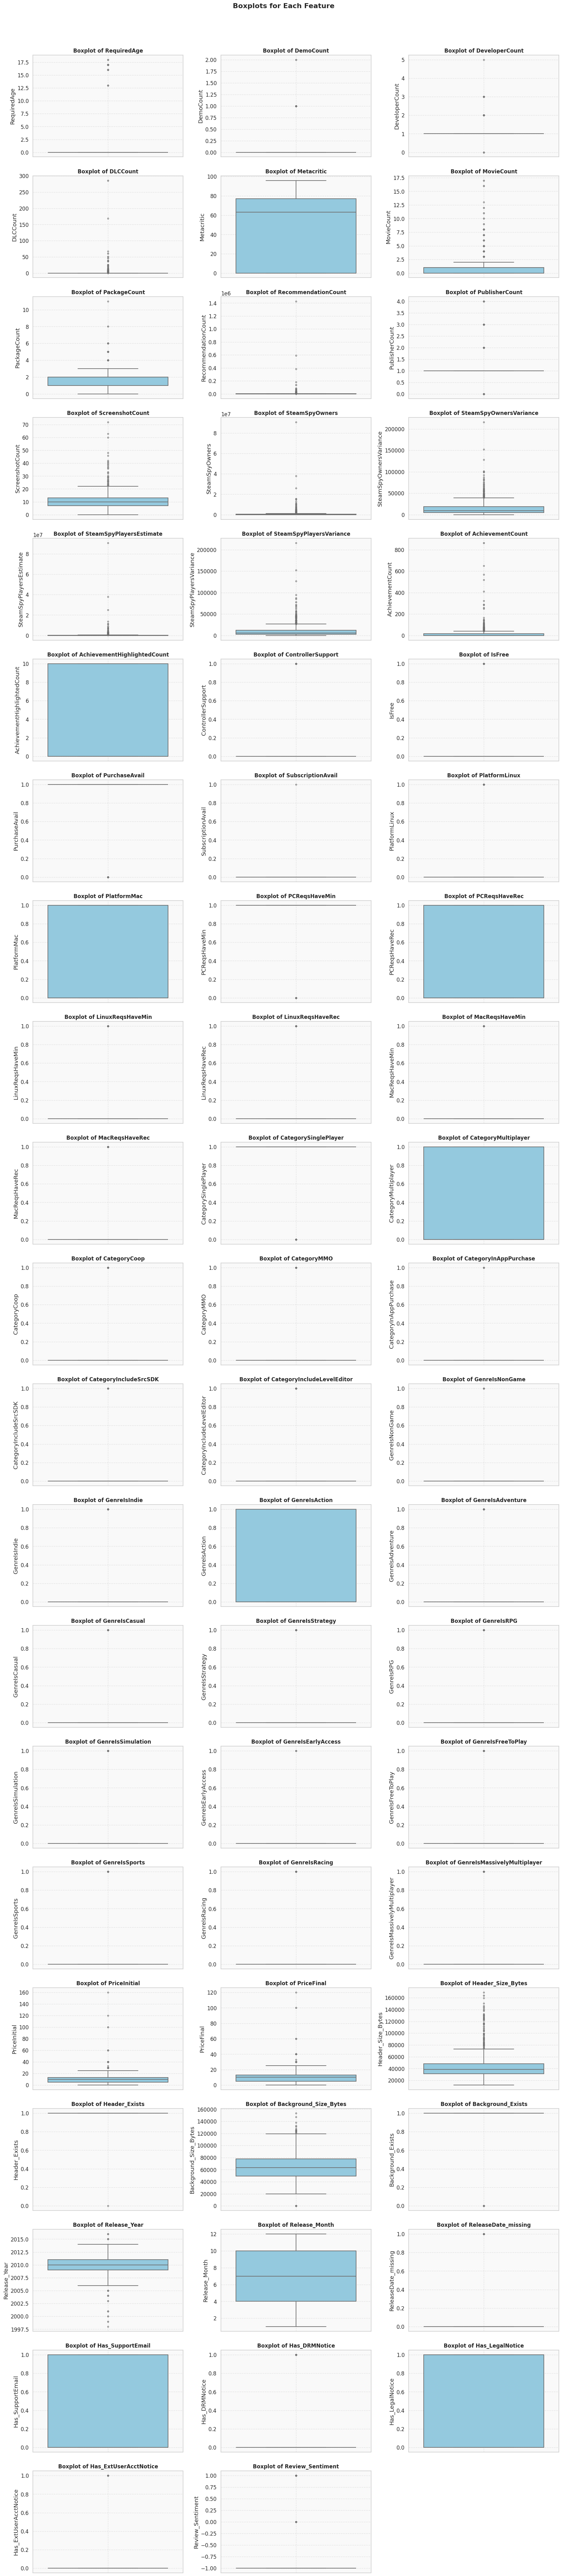

In [37]:
sns.set(style="whitegrid", font_scale=1.1)
cols = df.columns.drop(cat_cols)
n_cols = 3
n_rows = -(-len(cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', fliersize=3, linewidth=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, weight='bold')
    axes[i].set_facecolor('#f9f9f9')
    axes[i].grid(True, linestyle='--', alpha=0.5)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots for Each Feature", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 17-Log transform only true numeric, skewed, non-binary columns.

In [38]:
skew_threshold = 1
exclude_log_cols = set(binary_like_cols + ["Release_Year", "Release_Month"])
exclude_log_cols = {c for c in exclude_log_cols if c in df.columns}
num_cols = df.select_dtypes(include=np.number).columns.tolist()
log_cols = [
    col for col in num_cols
    if col not in exclude_log_cols
    and df[col].skew() > skew_threshold
    and (df[col] >= 0).all()]
print("Columns to log:", log_cols)
for col in log_cols:
  df[col] = np.log1p(df[col])

Columns to log: ['RequiredAge', 'DemoCount', 'DeveloperCount', 'DLCCount', 'MovieCount', 'PackageCount', 'RecommendationCount', 'PublisherCount', 'ScreenshotCount', 'SteamSpyOwners', 'SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance', 'AchievementCount', 'PriceInitial', 'PriceFinal', 'Header_Size_Bytes']


### 18-Final checks.

In [39]:
print("Final shape:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())

Final shape: (1412, 79)
Remaining missing values: 10537


In [40]:
df.head()

,ResponseName,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,MovieCount,PackageCount,RecommendationCount,PublisherCount,...,Website_Authority,Release_Year,Release_Month,ReleaseDate_missing,Game_Description,Has_SupportEmail,Has_DRMNotice,Has_LegalNotice,Has_ExtUserAcctNotice,Review_Sentiment
0,Counter-Strike,0.0,0.0,0.693147,0.0,88,0.0,0.693147,11.141746,0.693147,...,Custom_Studio,2000,11,0,Play the worlds number 1 online action game. E...,0,0,0,0,-1
1,Team Fortress Classic,0.0,0.0,0.693147,0.0,0,0.0,0.693147,7.799753,0.693147,...,Custom_Studio,1999,4,0,One of the most popular online action games of...,0,0,0,0,-1
2,Day of Defeat,0.0,0.0,0.693147,0.0,79,0.0,0.693147,7.749322,0.693147,...,Custom_Studio,2003,5,0,Enlist in an intense brand of Axis vs. Allied ...,0,0,0,0,-1
3,Deathmatch Classic,0.0,0.0,0.693147,0.0,0,0.0,0.693147,6.790097,0.693147,...,Custom_Studio,2001,6,0,Enjoy fast-paced multiplayer gaming with Death...,0,0,0,0,-1
4,Half-Life: Opposing Force,0.0,0.0,0.693147,0.0,0,0.0,0.693147,7.984463,0.693147,...,Custom_Studio,1999,11,0,Return to the Black Mesa Research Facility as ...,0,0,0,0,-1


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412 entries, 0 to 1411
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ResponseName                 1412 non-null   object 
 1   RequiredAge                  1412 non-null   float64
 2   DemoCount                    1412 non-null   float64
 3   DeveloperCount               1412 non-null   float64
 4   DLCCount                     1412 non-null   float64
 5   Metacritic                   1412 non-null   int64  
 6   MovieCount                   1412 non-null   float64
 7   PackageCount                 1412 non-null   float64
 8   RecommendationCount          1412 non-null   float64
 9   PublisherCount               1412 non-null   float64
 10  ScreenshotCount              1412 non-null   float64
 11  SteamSpyOwners               1412 non-null   float64
 12  SteamSpyOwnersVariance       1412 non-null   float64
 13  SteamSpyPlayersEst

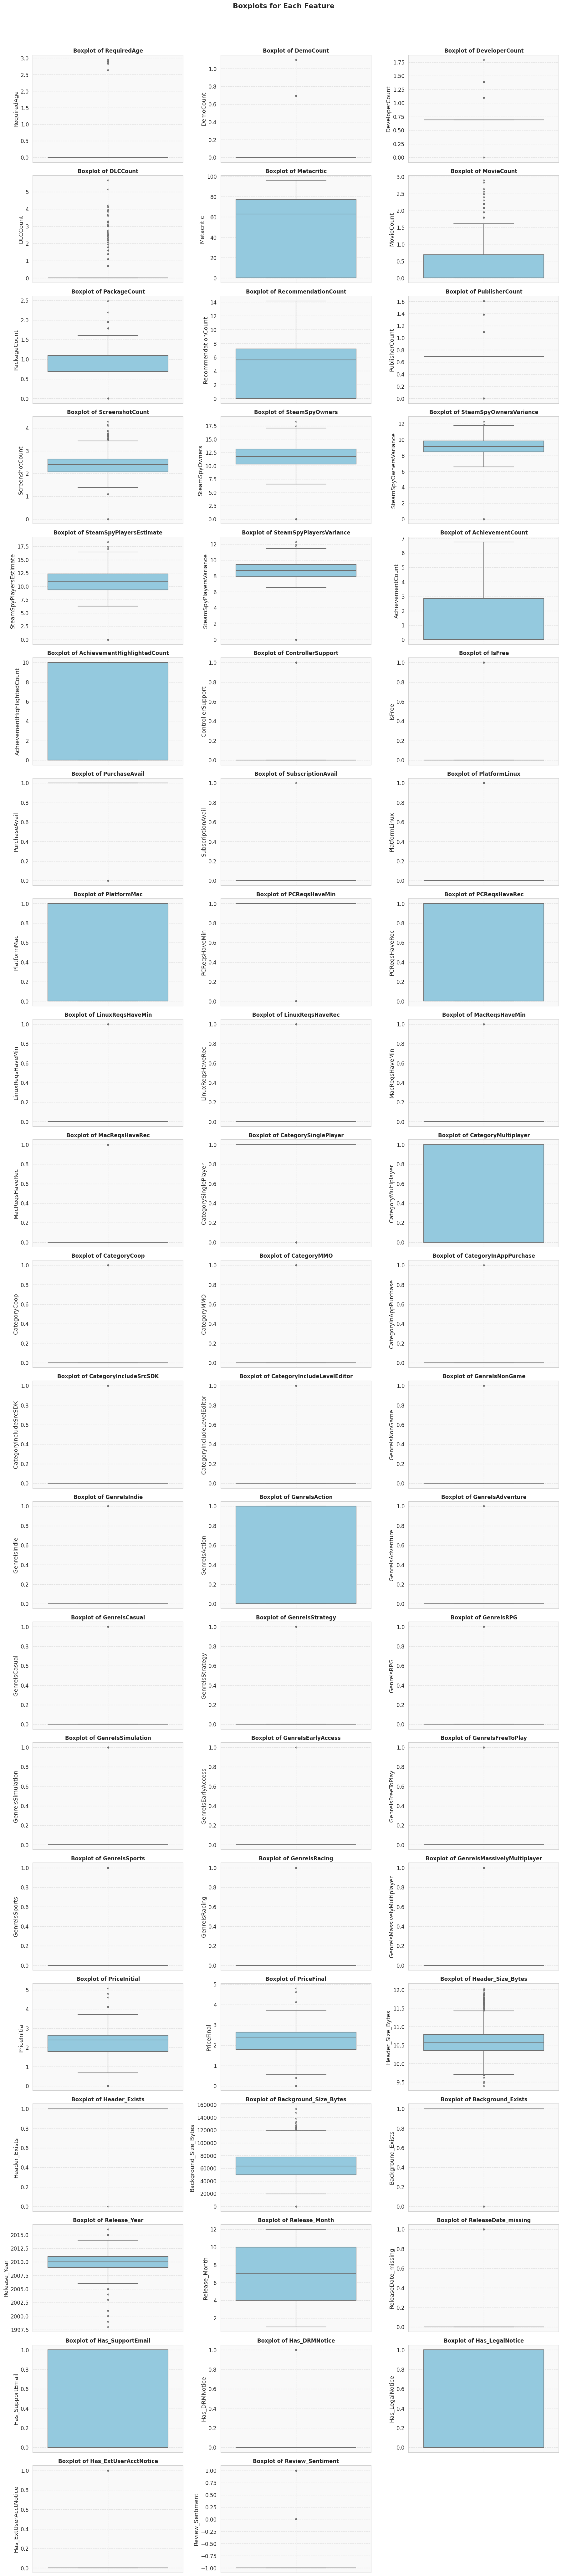

In [42]:
sns.set(style="whitegrid", font_scale=1.1)
cols = df.columns.drop(cat_cols)
n_cols = 3
n_rows = -(-len(cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', fliersize=3, linewidth=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, weight='bold')
    axes[i].set_facecolor('#f9f9f9')
    axes[i].grid(True, linestyle='--', alpha=0.5)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots for Each Feature", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [43]:
df.to_csv('data_preprocessed.csv', index=False)

In [44]:
from google.colab import files
files.download('data_preprocessed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
df = pd.read_csv("/content/data_preprocessed (6).csv")

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ResponseName                 410 non-null    object 
 1   RequiredAge                  410 non-null    float64
 2   DemoCount                    410 non-null    float64
 3   DeveloperCount               410 non-null    float64
 4   DLCCount                     410 non-null    float64
 5   Metacritic                   410 non-null    int64  
 6   MovieCount                   410 non-null    float64
 7   PackageCount                 410 non-null    float64
 8   RecommendationCount          410 non-null    float64
 9   PublisherCount               410 non-null    float64
 10  ScreenshotCount              410 non-null    float64
 11  SteamSpyOwners               410 non-null    float64
 12  SteamSpyOwnersVariance       410 non-null    float64
 13  SteamSpyPlayersEstim

### 19 - Cap outliers using IQR Winsorizing on skewed numeric columns

In [48]:
exclude_from_capping = (
    binary_like_cols
    + ["Release_Year", "Release_Month", "RecommendationCount"]
)
exclude_from_capping = {c for c in exclude_from_capping if c in df.columns}

# Only cap numeric columns that are still skewed after log transform
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cap_candidates = [
    col for col in num_cols
    if col not in exclude_from_capping
    and abs(df[col].skew()) > 1.0
]
print("Columns to winsorize:", cap_candidates)

capped_report = []

for col in cap_candidates:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)

    capped_report.append({
        "column": col,
        "lower_bound": round(lower, 4),
        "upper_bound": round(upper, 4),
        "outliers_capped": n_outliers,
        "skew_after": round(df[col].skew(), 4)
    })

print(pd.DataFrame(capped_report).to_string(index=False))


Columns to winsorize: ['RequiredAge', 'DemoCount', 'DeveloperCount', 'DLCCount', 'MovieCount', 'PublisherCount', 'SteamSpyOwners', 'SteamSpyOwnersVariance', 'SteamSpyPlayersVariance', 'AchievementCount', 'AchievementHighlightedCount', 'PriceInitial', 'PriceFinal', 'Review_Sentiment']
                     column  lower_bound  upper_bound  outliers_capped  skew_after
                RequiredAge       0.0000       0.0000               69      0.0000
                  DemoCount      -1.0397       1.7329                0      1.1311
             DeveloperCount       0.6931       0.6931               25      0.0000
                   DLCCount       0.0000       0.0000               27      0.0000
                 MovieCount      -1.0397       1.7329               16      0.9197
             PublisherCount       0.6931       0.6931               30      0.0000
             SteamSpyOwners       6.8909      17.2226                6      0.0515
     SteamSpyOwnersVariance       6.7115      11.87

### 20 - Convert boolean columns to int

In [49]:
bool_cols = df.select_dtypes(include="bool").columns.tolist()

print(f"Boolean columns found: {len(bool_cols)}")
print(bool_cols)

df[bool_cols] = df[bool_cols].astype(int)

remaining_bool = df.select_dtypes(include="bool").columns.tolist()
print(f"\nBool columns remaining after conversion: {len(remaining_bool)}")
print("Sample values:")
print(df[bool_cols].head(3))

Boolean columns found: 34
['ControllerSupport', 'IsFree', 'PurchaseAvail', 'SubscriptionAvail', 'PlatformLinux', 'PlatformMac', 'PCReqsHaveMin', 'PCReqsHaveRec', 'LinuxReqsHaveMin', 'LinuxReqsHaveRec', 'MacReqsHaveMin', 'MacReqsHaveRec', 'CategorySinglePlayer', 'CategoryMultiplayer', 'CategoryCoop', 'CategoryMMO', 'CategoryInAppPurchase', 'CategoryIncludeSrcSDK', 'CategoryIncludeLevelEditor', 'GenreIsNonGame', 'GenreIsIndie', 'GenreIsAction', 'GenreIsAdventure', 'GenreIsCasual', 'GenreIsStrategy', 'GenreIsRPG', 'GenreIsSimulation', 'GenreIsEarlyAccess', 'GenreIsFreeToPlay', 'GenreIsSports', 'GenreIsRacing', 'GenreIsMassivelyMultiplayer', 'Header_Exists', 'Background_Exists']

Bool columns remaining after conversion: 0
Sample values:
   ControllerSupport  IsFree  PurchaseAvail  SubscriptionAvail  PlatformLinux  \
0                  0       0              1                  0              1   
1                  0       0              1                  0              1   
2             

### 21 - Encode SupportedLanguages and PopularUserTags into numeric features

In [50]:
import ast

# parse the tuple-string back into a real tuple
def parse_tuple(val):
    if pd.isna(val):
        return ()
    if isinstance(val, tuple):
        return val
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, tuple) else ()
    except:
        return ()

# SupportedLanguages
if "SupportedLanguages" in df.columns:
    df["SupportedLanguages"] = df["SupportedLanguages"].apply(parse_tuple)
    df["language_count"] = df["SupportedLanguages"].apply(len)
    # supports English (most common language)
    df["has_english"] = df["SupportedLanguages"].apply(
        lambda x: 1 if any("english" in lang for lang in x) else 0
    )
    # drop original tuple columns, ignore if already dropped
    df.drop(columns=["SupportedLanguages"], inplace=True, errors='ignore')
else:
    # If the column is already dropped, ensure the generated columns exist with default values
    if "language_count" not in df.columns:
        df["language_count"] = 0
    if "has_english" not in df.columns:
        df["has_english"] = 0

# PopularUserTags
if "PopularUserTags" in df.columns:
    df["PopularUserTags"] = df["PopularUserTags"].apply(parse_tuple)

    df["tag_count"] = df["PopularUserTags"].apply(len)

    # Top 10 most frequent tags to binary indicator columns
    from collections import Counter

    all_tags = [tag for tags in df["PopularUserTags"] for tag in tags]
    if all_tags:
        top_tags = [tag for tag, _ in Counter(all_tags).most_common(10)]
        print("Top 10 tags:", top_tags)

        for tag in top_tags:
            col_name = f"tag_{tag.replace(' ', '_').replace('-', '_')}"
            # Check if column already exists before creating to prevent errors on rerun
            if col_name not in df.columns:
                df[col_name] = df["PopularUserTags"].apply(lambda x: 1 if tag in x else 0)
    else:
        print("No popular user tags found to extract.")

    # drop original tuple columns
    df.drop(columns=["PopularUserTags"], inplace=True, errors='ignore')
else:
    if "tag_count" not in df.columns:
        df["tag_count"] = 0


new_cols = []
if "language_count" in df.columns: new_cols.append("language_count")
if "has_english" in df.columns: new_cols.append("has_english")
if "tag_count" in df.columns: new_cols.append("tag_count")
# dynamically created tag columns
for col in df.columns:
    if col.startswith("tag_") and col not in new_cols and col != "tag_count":
        new_cols.append(col)

print(f"\nNew columns added ({len(new_cols)}):", new_cols)
# describe columns
existing_new_cols_for_describe = [col for col in new_cols if col in df.columns]
if existing_new_cols_for_describe:
    print(df[existing_new_cols_for_describe].describe())
else:
    print("No new tag/language columns to describe.")

Top 10 tags: ['singleplayer', 'action', 'classic', 'shooter', 'multiplayer', 'strategy', 'fps', 'adventure', 'first-person', 'sci-fi']

New columns added (13): ['language_count', 'has_english', 'tag_count', 'tag_singleplayer', 'tag_action', 'tag_classic', 'tag_shooter', 'tag_multiplayer', 'tag_strategy', 'tag_fps', 'tag_adventure', 'tag_first_person', 'tag_sci_fi']
       language_count  has_english   tag_count  tag_singleplayer  tag_action  \
count      410.000000   410.000000  410.000000        410.000000  410.000000   
mean         1.541463     0.992683    7.660976          0.570732    0.504878   
std          1.624834     0.085330    3.275409          0.495576    0.500587   
min          0.000000     0.000000    1.000000          0.000000    0.000000   
25%          1.000000     1.000000    5.000000          0.000000    0.000000   
50%          1.000000     1.000000   10.000000          1.000000    1.000000   
75%          1.000000     1.000000   10.000000          1.000000    1.00

### 22 - Drop pure identifier and already-flagged text columns

In [51]:
# near-unique identifier, so, it cannot be encoded meaningfully
df.drop(columns=["ResponseName"], inplace=True, errors='ignore')

# Has_SupportEmail already encodes presence of SupportEmail
df.drop(columns=["SupportEmail"], inplace=True, errors='ignore')

# Has_LegalNotice already encodes presence of SupportEmail
df.drop(columns=["LegalNotice"], inplace=True, errors='ignore')

print("Current shape:", df.shape)

Current shape: (410, 87)


 ### 23 - Extract features from PCMinReqsText

In [52]:
import re

# Extraction functions
def extract_ram_gb(text):
    if pd.isna(text): return np.nan
    text = text.lower()
    m = re.search(r'(\d+(?:\.\d+)?)\s*gb', text)
    if m: return float(m.group(1))
    m = re.search(r'(\d+(?:\.\d+)?)\s*mb', text)
    if m: return round(float(m.group(1)) / 1024, 4)
    return np.nan

def has_directx(text):
    if pd.isna(text): return 0
    return 1 if "directx" in text.lower() else 0

# Extract features
df["pc_min_ram_gb"]    = df["PCMinReqsText"].apply(extract_ram_gb)
df["pc_min_word_count"] = df["PCMinReqsText"].fillna("").apply(lambda x: len(x.split()))
df["pc_min_has_directx"]= df["PCMinReqsText"].apply(has_directx)

# Fill missing RAM with median
ram_median = df["pc_min_ram_gb"].median()
df["pc_min_ram_gb"] = df["pc_min_ram_gb"].fillna(ram_median)

# dropping raw column
df.drop(columns=["PCMinReqsText"], inplace=True)
print("Current shape:", df.shape)


Current shape: (410, 89)


### 24 - Extract features from PCRecReqsText, justify, then drop.

In [53]:
# feature 1: has_pc_rec_reqs — does the game bother to list rec specs?
df["has_pc_rec_reqs"] = df["PCRecReqsText"].notna().astype(int)

# feature 2: pc_rec_ram_gb — recommended RAM where available
df["pc_rec_ram_gb"] = df["PCRecReqsText"].apply(extract_ram_gb)
ram_rec_median = df["pc_rec_ram_gb"].median()
df["pc_rec_ram_gb"] = df["pc_rec_ram_gb"].fillna(ram_rec_median)

# feature 3: pc_rec_word_count — complexity of recommended spec
df["pc_rec_word_count"] = df["PCRecReqsText"].fillna("").apply(lambda x: len(x.split()))

# dopping raw column
df.drop(columns=["PCRecReqsText"], inplace=True)

# Compare rec RAM vs min RAM
print("Correlation between pc_rec_ram_gb and pc_min_ram_gb:",
      round(df["pc_rec_ram_gb"].corr(df["pc_min_ram_gb"]), 4))

Correlation between pc_rec_ram_gb and pc_min_ram_gb: 0.2751


### 25 - Extract features from MacMinReqsText

In [54]:
# LinuxMinReqsText
non_null_count = df["LinuxMinReqsText"].notna().sum()
# most rows are null, so, any extracted numeric feature would be, median-filled making it near-constant.
# A binary flag is the only honest signal
df["has_linux_min_reqs"] = df["LinuxMinReqsText"].notna().astype(int)
# drop raw col
df.drop(columns=["LinuxMinReqsText"], inplace=True)


# MacMinReqsText
non_null_count = df["MacMinReqsText"].notna().sum()
# same as LinuxMinReqsText
df["has_mac_min_reqs"] = df["MacMinReqsText"].notna().astype(int)
df.drop(columns=["MacMinReqsText"], inplace=True)

# Correlation between Linux and mac
corr_linux = df["has_mac_min_reqs"].corr(df["has_linux_min_reqs"])
print(f"Corr of has_mac_min_reqs with has_linux_min_reqs : {corr_linux:.4f}")

Corr of has_mac_min_reqs with has_linux_min_reqs : 0.5705


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 91 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RequiredAge                  410 non-null    float64
 1   DemoCount                    410 non-null    float64
 2   DeveloperCount               410 non-null    float64
 3   DLCCount                     410 non-null    float64
 4   Metacritic                   410 non-null    int64  
 5   MovieCount                   410 non-null    float64
 6   PackageCount                 410 non-null    float64
 7   RecommendationCount          410 non-null    float64
 8   PublisherCount               410 non-null    float64
 9   ScreenshotCount              410 non-null    float64
 10  SteamSpyOwners               410 non-null    float64
 11  SteamSpyOwnersVariance       410 non-null    float64
 12  SteamSpyPlayersEstimate      410 non-null    float64
 13  SteamSpyPlayersVaria

### 26 - Semantic Embeddings of Game_Description.

In [57]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

model = SentenceTransformer("all-MiniLM-L6-v2")

emb = model.encode(
    df["Game_Description"].fillna("").tolist(),
    convert_to_numpy=True
)

pca = PCA(n_components=10)
desc10 = pca.fit_transform(emb)

for i in range(10):
    df[f"desc_semantic_{i}"] = desc10[:,i]

df.drop(columns=["Game_Description"], inplace=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [61]:
# Show added semantic description features
semantic_features = [col for col in df.columns if col.startswith("desc_semantic_")]

print(f"Number of features added: {len(semantic_features)}")
print("\nAdded features:")
for f in semantic_features:
    print(f)

# preview values
print("\nSample values:")
print(df[semantic_features].head())

# how much information the 10 features keep
print("\nExplained variance ratio:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"desc_semantic_{i}: {v:.4f}")

print("\nTotal variance captured:",
      round(pca.explained_variance_ratio_.sum(),4))

Number of features added: 10

Added features:
desc_semantic_0
desc_semantic_1
desc_semantic_2
desc_semantic_3
desc_semantic_4
desc_semantic_5
desc_semantic_6
desc_semantic_7
desc_semantic_8
desc_semantic_9

Sample values:
   desc_semantic_0  desc_semantic_1  desc_semantic_2  desc_semantic_3  \
0         0.314677         0.021512         0.010930        -0.014065   
1         0.325027         0.092933        -0.010472        -0.072651   
2         0.493025         0.046035         0.233296        -0.093713   
3         0.048731         0.105736        -0.042868        -0.149751   
4        -0.008234        -0.001277         0.056839        -0.094563   

   desc_semantic_4  desc_semantic_5  desc_semantic_6  desc_semantic_7  \
0         0.042400        -0.032770        -0.153073         0.083754   
1        -0.096127        -0.014021        -0.244369         0.103707   
2         0.104775        -0.019125        -0.153621         0.080007   
3        -0.220751         0.174026         0.0

### Drop very high-missing columns that are not raw text columns.

In [58]:
missing_ratio = df.isna().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.80].index.tolist()
if high_missing_cols:
  print("Dropped high-missing columns:", high_missing_cols)
  df.drop(columns=high_missing_cols, inplace=True)

Dropped high-missing columns: ['DRMNotice', 'ExtUserAcctNotice', 'LinuxRecReqsText', 'MacRecReqsText']


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 96 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RequiredAge                  410 non-null    float64
 1   DemoCount                    410 non-null    float64
 2   DeveloperCount               410 non-null    float64
 3   DLCCount                     410 non-null    float64
 4   Metacritic                   410 non-null    int64  
 5   MovieCount                   410 non-null    float64
 6   PackageCount                 410 non-null    float64
 7   RecommendationCount          410 non-null    float64
 8   PublisherCount               410 non-null    float64
 9   ScreenshotCount              410 non-null    float64
 10  SteamSpyOwners               410 non-null    float64
 11  SteamSpyOwnersVariance       410 non-null    float64
 12  SteamSpyPlayersEstimate      410 non-null    float64
 13  SteamSpyPlayersVaria

In [62]:
df.to_csv('data_preprocessed.csv', index=False)

In [63]:
from google.colab import files
files.download('data_preprocessed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>